In [40]:
# Setup
import matplotlib.pyplot as plt
import pandas as pd

from helpers.backtest import (
    align_prices,
    load_ntsg_usd,
    load_prices,
    monthly_rebalanced_returns,
    splice_proxy_to_actual,
    summary_metrics,
    weekly_returns,
)

OUTPUT_DIR = "outputs"
MODEL_TICKERS = ("NTSG", "COM", "DBMF", "GDE", "TAIL")
MODEL_WEIGHTS = pd.Series({"NTSG": 0.60, "COM": 0.10, "DBMF": 0.15, "GDE": 0.10, "TAIL": 0.05})
BENCHMARK_WEIGHTS = pd.Series({"VT": 0.60, "BNDW": 0.40})
EQUITY_BENCHMARK = "MSCI World Price USD"
WINDOW = 52


def weekly_price_returns(prices: pd.Series) -> pd.Series:
    """Return complete Friday-labelled weekly returns."""
    weekly_prices = prices.resample("W-FRI").last().dropna()
    if weekly_prices.index[-1] > prices.index[-1]:
        weekly_prices = weekly_prices.iloc[:-1]
    return weekly_prices.pct_change()


def plot_rolling_correlations(series: dict[str, pd.Series]) -> None:
    """Plot rolling weekly correlations with the USD equity benchmark."""
    benchmark = weekly_returns("MSCI_WORLD_USD.CSV", EQUITY_BENCHMARK)
    fig, axes = plt.subplots(len(series), 1, figsize=(12, 2.5 * len(series)), sharex=True)
    for axis, (name, prices) in zip(axes, series.items()):
        correlation = weekly_price_returns(prices).rolling(WINDOW).corr(benchmark).dropna()
        axis.plot(correlation.index, correlation, linewidth=1.3)
        axis.axhline(0, color="black", linewidth=0.8)
        axis.set(title=f"{name} vs {EQUITY_BENCHMARK}", ylabel="Correlation", ylim=(-1, 1))
        axis.grid(axis="y", alpha=0.3)
    fig.suptitle(f"{WINDOW}-week rolling correlation of weekly returns", y=1.005)
    fig.tight_layout()
    plt.show()

## 1. Rolling correlations with global equities

Weekly adjusted-price returns are sampled from complete Friday-labelled weeks. The benchmark is the MSCI World **price** index in USD, so it excludes dividends, emerging markets, and small caps. NTSG is converted from its EUR listing to USD before comparison.

Each estimate uses 52 observations. The actual-ETF histories are short, non-synchronous closing times remain, and the resulting curves are descriptive rather than evidence of stable diversification.

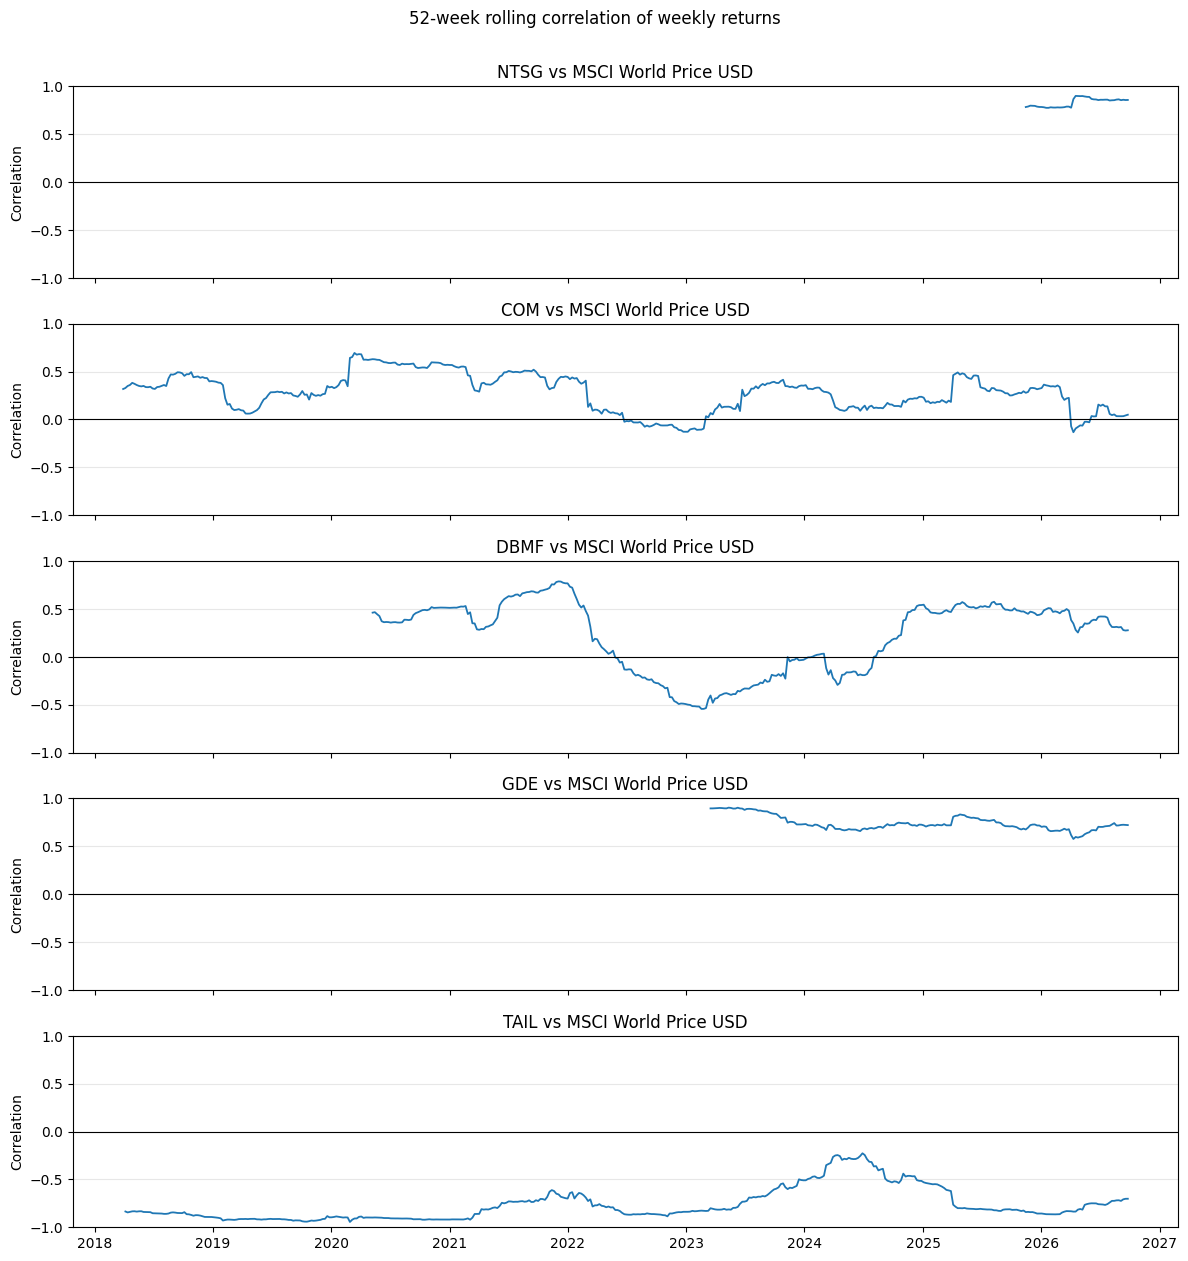

In [41]:
# Actual ETF histories, all expressed in USD.
actual_correlation_prices = {
    ticker: load_ntsg_usd() if ticker == "NTSG" else load_prices(f"{ticker}.CSV", ticker)
    for ticker in MODEL_TICKERS
}
plot_rolling_correlations(actual_correlation_prices)

### Underlying exposure proxies

These are broad descriptive proxies, not reconstructions of the model ETFs. They follow the project proxy set: VT, BNDW, PDBC, WTMF, SPY, GLD, and actual TAIL. Their holdings, leverage, duration, roll rules, and inception dates differ from the portfolio instruments.

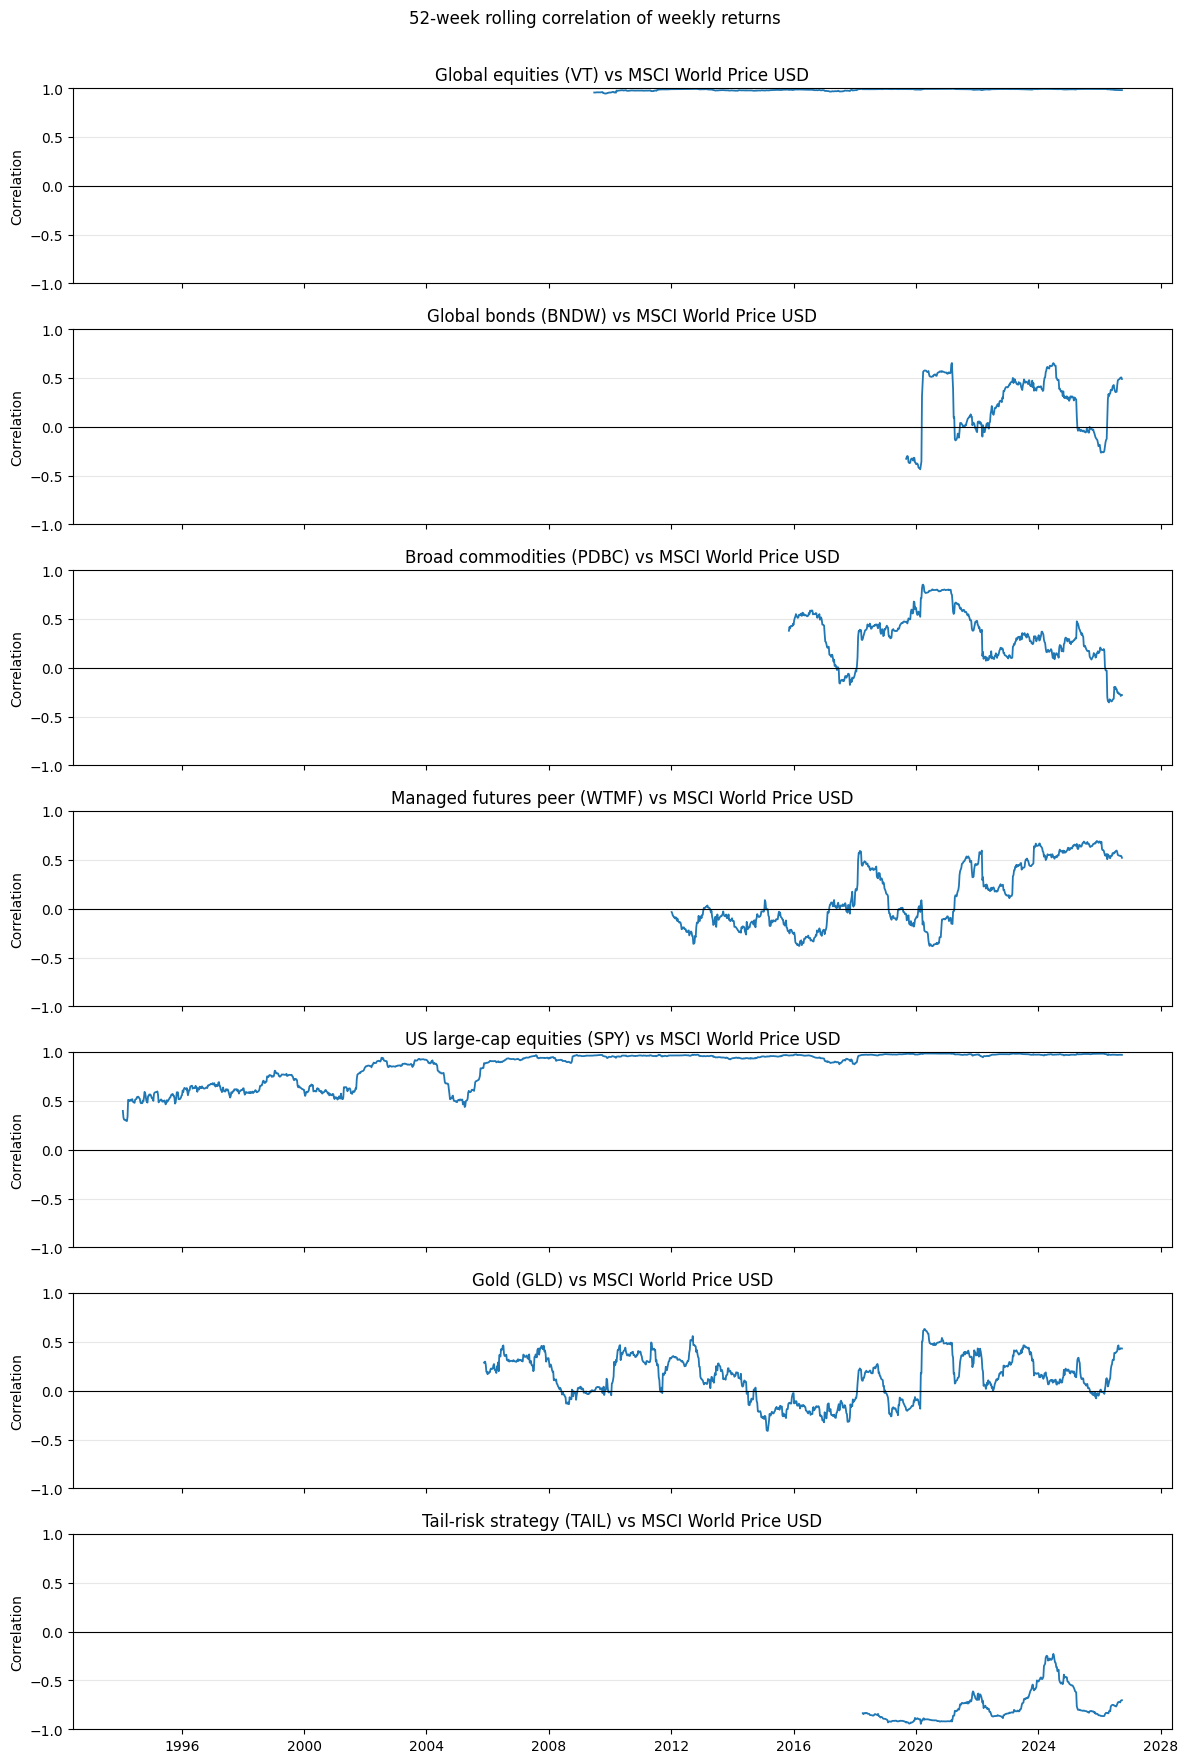

In [42]:
# Broad exposure proxies from the project specification.
underlying_prices = {
    "Global equities (VT)": load_prices("VT.CSV", "VT"),
    "Global bonds (BNDW)": load_prices("BNDW.CSV", "BNDW"),
    "Broad commodities (PDBC)": load_prices("PDBC.CSV", "PDBC"),
    "Managed futures peer (WTMF)": load_prices("WTMF.CSV", "WTMF"),
    "US large-cap equities (SPY)": load_prices("SPY.CSV", "SPY"),
    "Gold (GLD)": load_prices("GLD.CSV", "GLD"),
    "Tail-risk strategy (TAIL)": load_prices("TAIL.CSV", "TAIL"),
}
plot_rolling_correlations(underlying_prices)

## 2. Portfolio backtests

Daily adjusted prices are expressed in USD and aligned to one common calendar. Short market-holiday gaps are forward-filled; gaps longer than five observations are dropped. Portfolios rebalance at month-end close and exclude trading costs and taxes.

Benchmarks are a monthly rebalanced 60% VT / 40% BNDW portfolio and 100% VT. Sharpe and Sortino use the effective federal funds rate as cash. Results include worst calendar-year and one-year rolling-return statistics, but the actual-ETF window remains too short for reliable inference.

In [43]:
# Shared benchmark and cash series.
BENCHMARK_PRICES = pd.concat(
    [load_prices("VT.CSV", "VT"), load_prices("BNDW.CSV", "BNDW")], axis=1, sort=True
)
CASH_PRICES = load_prices("USD_CASH_EFFR.CSV", "USD cash")


def run_comparison(model_prices: pd.DataFrame, title: str, summary_file: str) -> pd.DataFrame:
    """Compare all strategies on one aligned daily calendar."""
    prices = align_prices(pd.concat([model_prices, BENCHMARK_PRICES], axis=1, sort=True))
    returns = pd.DataFrame({
        "Model portfolio": monthly_rebalanced_returns(prices, MODEL_WEIGHTS),
        "60/40 VT/BNDW": monthly_rebalanced_returns(prices, BENCHMARK_WEIGHTS),
        "VT": prices["VT"].pct_change().fillna(0.0),
    })
    if returns.isna().any().any():
        raise ValueError("Strategies do not share a complete return calendar.")

    metrics = pd.DataFrame({name: summary_metrics(returns[name], CASH_PRICES) for name in returns}).T
    metrics.index.name = "Strategy"
    metrics.to_csv(f"{OUTPUT_DIR}/{summary_file}")
    print(f"{title}: {returns.index[0]:%Y-%m-%d} to {returns.index[-1]:%Y-%m-%d}")
    display(metrics)
    ((1 + returns).cumprod().sub(1) * 100).plot(
        figsize=(12, 4), linewidth=1.5, grid=True, title=f"{title}: cumulative total return (%)"
    )
    plt.show()
    return returns

### 2a. Actual ETFs only

This is the least assumption-heavy test, but it begins in November 2024 and contains too little history for robust conclusions. NTSG is converted from its EUR listing to USD with daily EURUSD. Its Xetra close precedes the US close, so daily covariance, volatility, and drawdown remain timing-noisy.

NTSG 2024-11-13 to 2026-09-30: 18.99% in EUR, 27.03% in USD
Actual ETF backtest: 2024-11-13 to 2026-09-30


,Cumulative return,CAGR,Volatility,Max drawdown,Max drawdown period,Sharpe,Sortino,Calmar,Worst calendar year,1Y rolling return (5th percentile),1Y rolling return (median),1Y rolling return (95th percentile)
Strategy,,,,,,,,,,,,
Model portfolio,0.31506,0.156993,0.108574,-0.106836,2025-02-18 to 2025-04-09,1.023994,1.459349,1.469477,-0.011181,0.158718,0.229156,0.293899
60/40 VT/BNDW,0.22227,0.112784,0.099104,-0.098772,2025-02-18 to 2025-04-08,0.718515,1.046084,1.14186,-0.00888,0.109594,0.149758,0.210263
VT,0.362733,0.179139,0.15754,-0.165145,2025-02-18 to 2025-04-08,0.867196,1.277951,1.084734,-0.016377,0.170503,0.230173,0.340095


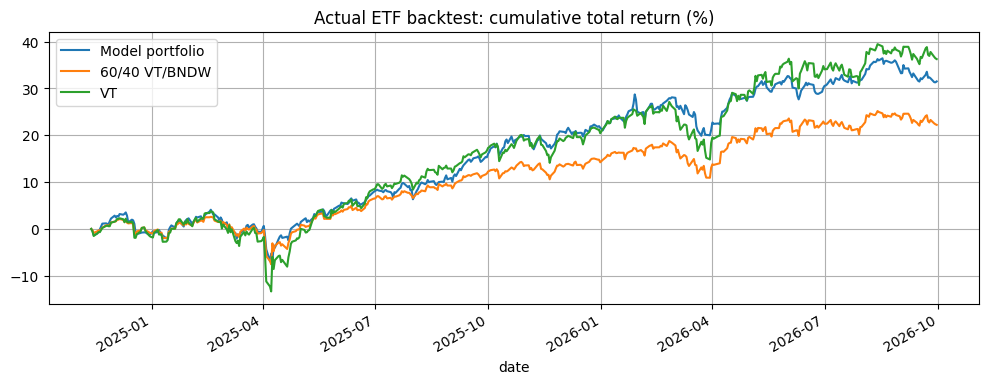

In [44]:
# Actual ETF portfolio.
ntsg_eur = load_prices("NTSG.CSV", "NTSG EUR")
ntsg_usd = load_ntsg_usd()
print(
    f"NTSG {ntsg_eur.index[0]:%Y-%m-%d} to {ntsg_eur.index[-1]:%Y-%m-%d}: "
    f"{ntsg_eur.iloc[-1] / ntsg_eur.iloc[0] - 1:.2%} in EUR, "
    f"{ntsg_usd.iloc[-1] / ntsg_usd.iloc[0] - 1:.2%} in USD"
)
actual_prices = pd.concat(
    [
        ntsg_usd,
        load_prices("COM.CSV", "COM"),
        load_prices("DBMF.CSV", "DBMF"),
        load_prices("GDE.CSV", "GDE"),
        load_prices("TAIL.CSV", "TAIL"),
    ],
    axis=1,
    sort=True,
)
actual_returns = run_comparison(actual_prices, "Actual ETF backtest", "actual_etf_backtest_summary.csv")

### 2b. Synthetic sensitivity

This is a counterfactual exposure test, not investable historical performance. NTSG and GDE use present-day strategy approximations before fund inception and are spliced to actual returns afterward. The fixed NTSG regional weights, current methodologies, and current fees introduce look-ahead bias whose direction is unknown.

DBMF and TAIL are not backfilled because their disclosed rules are insufficient for reconstruction. DBMF therefore fixes the common start at May 2019. COM already existed by then, so its synthetic history is unnecessary and actual COM is used throughout.

Synthetic sensitivity: 2019-05-08 to 2026-09-30


,Cumulative return,CAGR,Volatility,Max drawdown,Max drawdown period,Sharpe,Sortino,Calmar,Worst calendar year,1Y rolling return (5th percentile),1Y rolling return (median),1Y rolling return (95th percentile)
Strategy,,,,,,,,,,,,
Model portfolio,1.252581,0.116026,0.127361,-0.224204,2020-02-19 to 2020-03-23,0.704441,0.975573,0.517504,-0.142026,-0.106573,0.137279,0.289359
60/40 VT/BNDW,0.808725,0.083405,0.116804,-0.223456,2020-02-12 to 2020-03-23,0.503122,0.69204,0.373253,-0.157555,-0.136687,0.114046,0.231068
VT,1.486705,0.131044,0.186979,-0.342362,2020-02-12 to 2020-03-23,0.601934,0.836658,0.382765,-0.180033,-0.158945,0.169998,0.37943


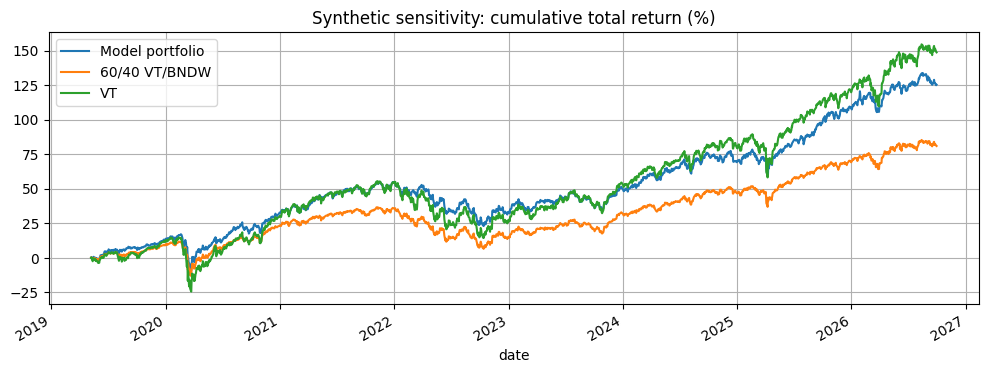

In [45]:
# Synthetic NTSG and GDE before inception; all other legs are actual ETFs.
extended_prices = pd.concat(
    [
        splice_proxy_to_actual("NTSG_proxy_extended.csv", ntsg_usd),
        load_prices("COM.CSV", "COM"),
        load_prices("DBMF.CSV", "DBMF"),
        splice_proxy_to_actual("GDE_proxy.csv", load_prices("GDE.CSV", "GDE")),
        load_prices("TAIL.CSV", "TAIL"),
    ],
    axis=1,
    sort=True,
)
extended_returns = run_comparison(
    extended_prices, "Synthetic sensitivity", "proxy_extended_backtest_summary.csv"
)

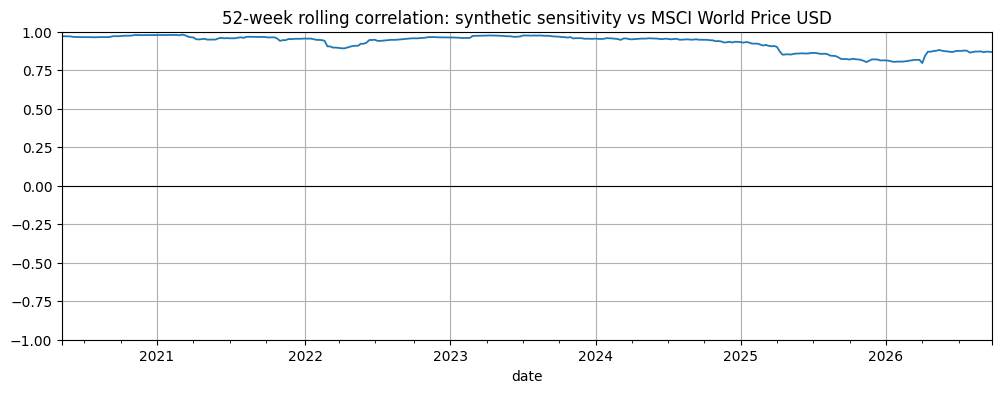

In [46]:
# Rolling equity correlation of the synthetic-sensitivity portfolio.
extended_wealth = (1 + extended_returns["Model portfolio"]).cumprod()
model_weekly = weekly_price_returns(extended_wealth)
msci_weekly = weekly_returns("MSCI_WORLD_USD.CSV", EQUITY_BENCHMARK)
model_correlation = model_weekly.rolling(WINDOW).corr(msci_weekly).dropna()
ax = model_correlation.plot(
    figsize=(12, 4),
    linewidth=1.3,
    grid=True,
    ylim=(-1, 1),
    title=f"{WINDOW}-week rolling correlation: synthetic sensitivity vs {EQUITY_BENCHMARK}",
)
ax.axhline(0, color="black", linewidth=0.8)
plt.show()

## Audit findings and interpretation

### Findings that could mislead conclusions

- **Selection bias:** The portfolio was selected after observing recent fund performance. The results are not out-of-sample evidence.
- **Look-ahead bias in synthetic history:** The extended NTSG and GDE series apply current strategy designs, current fees, and fixed historical proxy weights before fund inception. Their historical performance is counterfactual; the bias may be favorable or unfavorable.
- **Short actual sample:** The actual portfolio begins in November 2024. It has only one complete calendar year, so its CAGR, Sharpe, Sortino, Calmar, drawdown, and rolling statistics are unstable. The 2025 model return was 22.98%, but this is not evidence of a normal annual outcome.
- **NTSG reconstruction error:** The NTSG proxy uses broad equity and bond ETFs instead of the official ESG equity basket, sovereign futures, currency-linked weights, roll schedule, and multi-currency collateral.
- **GDE reconstruction error:** The GDE proxy uses fee-adjusted GLD minus cash instead of gold-futures returns and assumes quarterly resets that are not published fund rules.
- **Unreconstructed strategies:** DBMF's Dynamic Beta Engine and TAIL's option ladder cannot be reproduced from public information. WTMF and PPUT are peers or benchmarks, not substitutes.
- **COM simulated history:** The Auspice ABCTRI history before 2010-09-30 is issuer-simulated and benefits from hindsight. Actual COM is used in the portfolio tests.
- **Benchmark mismatch:** The model has approximately 138% gross notional exposure, while VT and the 60/40 benchmark do not. Direct CAGR comparisons therefore mix leverage, exposure design, and manager skill.
- **Currency and timing mismatch:** NTSG trades in EUR, its FX conversion and Xetra close are not synchronized with US-listed assets, and daily covariance, volatility, Sharpe, and drawdown contain non-synchronous-pricing noise.
- **Return-definition mismatch:** The correlation benchmark is the MSCI World price index, excluding dividends, while ETF prices are adjusted for distributions. Correlations describe co-movement, not total-return equivalence or downside protection.
- **Data and implementation risk:** Yahoo adjusted prices are unaudited. Holiday filling creates stale or zero-return observations, and longer missing-data gaps are dropped. Fees, spreads, commissions, taxes, market impact, futures margin changes, and option trading costs are excluded.
- **Cash-rate inconsistency:** Proxy construction uses DGS3MO, while Sharpe and Sortino use EFFR. This is an approximation, not a single consistent financing assumption.
- **Currency reporting gap:** Results are currently USD-only. The required EUR and CHF periodic-return analysis has not been implemented.

### Corrections applied

- NTSG is converted from EUR to USD before USD correlations and backtests.
- Model and benchmarks use one common daily calendar with a five-observation forward-fill limit.
- Incomplete terminal weeks and months are excluded from correlation and validation samples.
- The synthetic sensitivity backfills only NTSG and GDE. DBMF and TAIL remain actual-only; COM is actual throughout that test.
- Rolling correlations no longer use hindsight-defined crisis markers.
- Metrics now include complete-calendar-year returns, one-year rolling-return quantiles, and sample-frequency annualization.
- Futures sleeves are treated as notional profit-and-loss overlays rather than funded assets.

### Current validation facts

- Closed-month proxy correlations through August 2026 are 0.932 for NTSG, 0.987 for GDE, 0.989 for COM, and 0.279 for the WTMF-based DBMF peer.
- The actual USD backtest runs from 2024-11-13 to 2026-09-30; the synthetic sensitivity runs from 2019-05-08 to 2026-09-30.
- These figures support sensitivity analysis only. They do not establish that the model will outperform VT or 60/40 in future or investable historical periods.